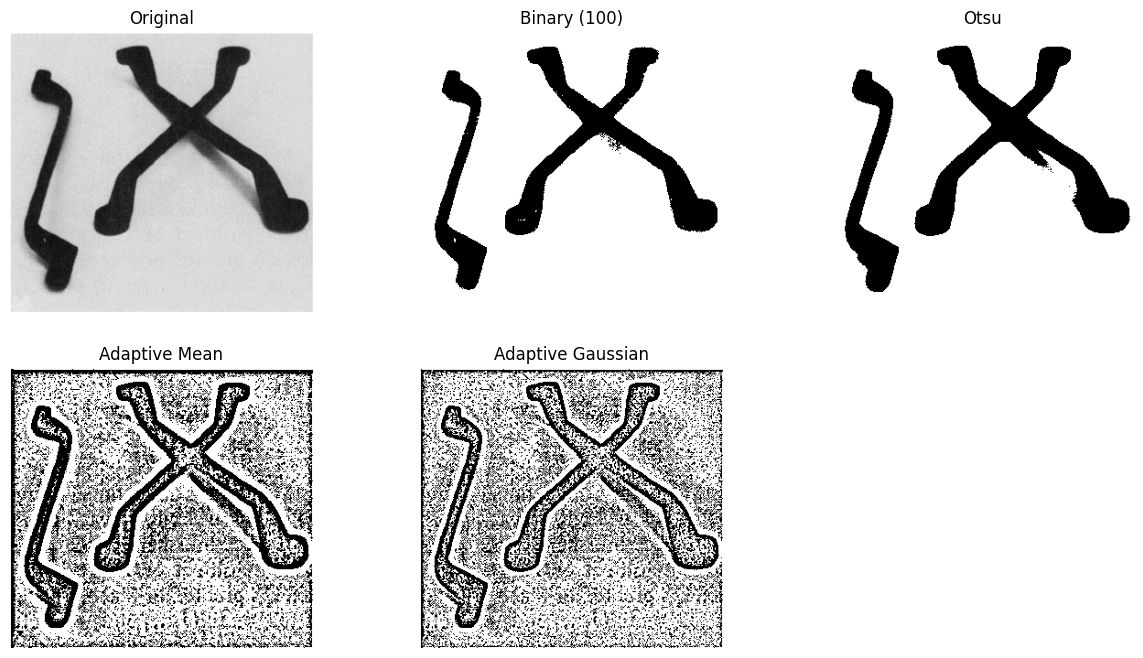

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = "thresholdingcontoh.png"

# Baca gambar dalam grayscale
img = cv2.imread(img, cv2.IMREAD_GRAYSCALE)


# Thresholding global
_, th_binary = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
_, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive Thresholding
th_adapt_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
th_adapt_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 11, 2)

# Tampilkan hasil
titles = ['Original', 'Binary (100)', 'Otsu', 'Adaptive Mean', 'Adaptive Gaussian']
images = [img, th_binary, th_otsu, th_adapt_mean, th_adapt_gauss]

plt.figure(figsize=(15,8))
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


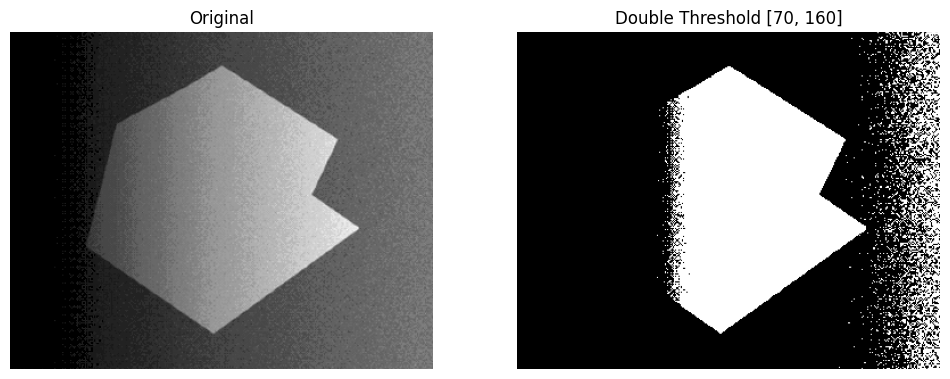

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = "thresholdingcontoh2.png"

# Baca gambar dalam grayscale
img = cv2.imread(img, cv2.IMREAD_GRAYSCALE)

# Threshold global dengan 2 nilai ambang
lower = 70   # batas bawah (ubah sesuai kebutuhan)
upper = 160  # batas atas (ubah sesuai kebutuhan)

# Hasil thresholding (range)
mask = cv2.inRange(img, lower, upper)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title(f"Double Threshold [{lower}, {upper}]")
plt.axis("off")

plt.show()

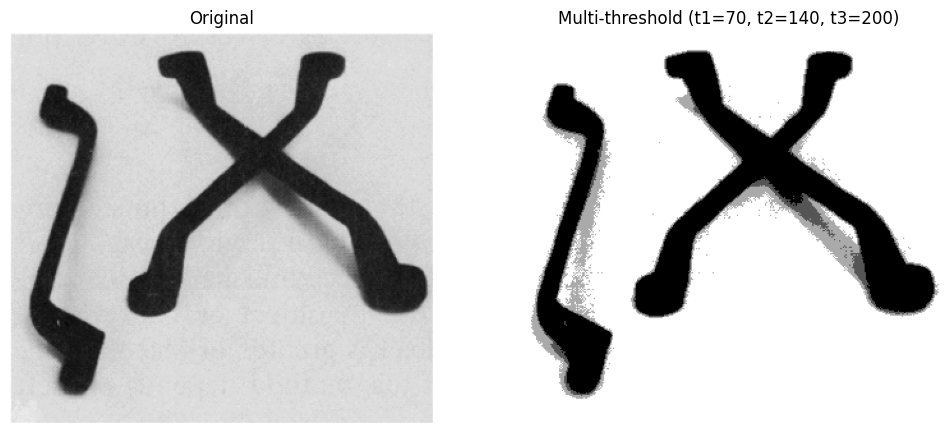

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = "thresholdingcontoh.png"

# Baca gambar dalam grayscale
img = cv2.imread(img, cv2.IMREAD_GRAYSCALE)

# Tiga nilai threshold
t1, t2, t3 = 70, 140, 200

# Buat citra kosong
result = np.zeros_like(img)

# Mapping sesuai range
result[(img >= 0)   & (img < t1)] = 0      # hitam
result[(img >= t1)  & (img < t2)] = 85     # abu-abu muda
result[(img >= t2)  & (img < t3)] = 170    # abu-abu lebih terang
result[(img >= t3)] = 255                  # putih

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title(f"Multi-threshold (t1={t1}, t2={t2}, t3={t3})")
plt.axis("off")

plt.show()


In [ ]:
# Install library yang dibutuhkan
!pip install opencv-python matplotlib --quiet

import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# Upload gambar dari komputer
uploaded = files.upload()

# Ambil nama file gambar yang diupload
for filename in uploaded.keys():
    img_path = filename

# Baca gambar dalam grayscale
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Thresholding global (nilai tetap)
_, th_binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Otsu Thresholding (otomatis cari nilai optimal)
_, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive Thresholding
th_adapt_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, 11, 2)
th_adapt_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 11, 2)

# Tampilkan hasil
titles = ['Original', 'Binary (127)', 'Otsu', 'Adaptive Mean', 'Adaptive Gaussian']
images = [img, th_binary, th_otsu, th_adapt_mean, th_adapt_gauss]

plt.figure(figsize=(15,8))
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


In [ ]:
# Install library yang dibutuhkan
!pip install opencv-python matplotlib scikit-image --quiet

import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
from skimage.filters import threshold_multiotsu

# Upload gambar dari komputer
uploaded = files.upload()

# Ambil nama file gambar yang diupload
for filename in uploaded.keys():
    img_path = filename
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# --- 1. Global Otsu ---
_, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# --- 2. Multi-Otsu otomatis ---
# Tentukan jumlah kelas (contoh: 3 kelas = 2 threshold)
thresholds = threshold_multiotsu(img, classes=3)
multi_otsu = np.digitize(img, bins=thresholds) * (255 // (len(thresholds)+1))

# --- Tampilkan hasil ---
titles = ["Original", "Global Otsu", "Multi-Otsu"]
images = [img, th_otsu, multi_otsu]

plt.figure(figsize=(15,8))
for i in range(len(images)):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.show()

print("Thresholds (Multi-Otsu):", thresholds)

**Region Growing**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


from google.colab import files
import numpy as np
from skimage.filters import threshold_multiotsu

# Upload gambar dari komputer
uploaded = files.upload()

# Ambil nama file gambar yang diupload
for filename in uploaded.keys():
    img_path = filename
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Seed point (bisa ubah sesuai kebutuhan)
seed = (100, 100)   # (y, x)
threshold = 15      # toleransi perbedaan intensitas

# Region Growing
h, w = img.shape
visited = np.zeros_like(img, dtype=bool)
segmented = np.zeros_like(img, dtype=np.uint8)

seed_value = img[seed]
queue = deque([seed])
visited[seed] = True

while queue:
    y, x = queue.popleft()
    segmented[y, x] = 255
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                if abs(int(img[ny, nx]) - int(seed_value)) < threshold:
                    visited[ny, nx] = True
                    queue.append((ny, nx))

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap="gray")
plt.title("Region Growing")
plt.axis("off")
plt.show()


**Region Splitting and Merging**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from google.colab import files
import numpy as np
from skimage.filters import threshold_multiotsu

# Upload gambar dari komputer
uploaded = files.upload()

# Ambil nama file gambar yang diupload
for filename in uploaded.keys():
    img_path = filename
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Threshold variansi untuk cek homogenitas
var_threshold = 500.0

# Recursive splitting function
def split_region(img, x, y, w, h, min_size=16):
    region = img[y:y+h, x:x+w]
    if region.size == 0:
        return []

    # cek homogenitas (variansi)
    if np.var(region) < var_threshold or w <= min_size or h <= min_size:
        return [(x, y, w, h)]

    # bagi jadi 4 kuadran
    half_w, half_h = w // 2, h // 2
    regions = []
    regions += split_region(img, x, y, half_w, half_h, min_size)
    regions += split_region(img, x + half_w, y, half_w, half_h, min_size)
    regions += split_region(img, x, y + half_h, half_w, half_h, min_size)
    regions += split_region(img, x + half_w, y + half_h, half_w, half_h, min_size)

    return regions

# Jalankan splitting
h, w = img.shape
regions = split_region(img, 0, 0, w, h)

# Buat citra hasil segmentasi
segmented = np.zeros_like(img)
for (x, y, rw, rh) in regions:
    mean_val = int(np.mean(img[y:y+rh, x:x+rw]))
    segmented[y:y+rh, x:x+rw] = mean_val

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title("Region Splitting & Merging")
plt.axis("off")
plt.show()


**Watershed**

In [ ]:
# Install OpenCV kalau belum ada
!pip install opencv-python matplotlib --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# === Upload Gambar dari Komputer ===
uploaded = files.upload()
for fn in uploaded.keys():
    img_path = fn

# === Load Gambar ===
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# === Preprocessing: Noise Removal ===
blur = cv2.GaussianBlur(gray, (5,5), 0)

# === Thresholding (Otsu) ===
ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# === Morphological Operations untuk Background ===
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Sure foreground area (pakai distance transform)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# === Marker Labelling ===
ret, markers = cv2.connectedComponents(sure_fg)

# Tambahkan 1 agar background bukan nol
markers = markers + 1

# Tandai area unknown sebagai 0
markers[unknown == 255] = 0

# === Terapkan Watershed ===
markers = cv2.watershed(image, markers)
segmented = image_rgb.copy()
segmented[markers == -1] = [255, 0, 0]  # boundary = merah

# === Tampilkan Hasil ===
fig, axs = plt.subplots(2, 3, figsize=(15,10))
axs[0,0].imshow(image_rgb); axs[0,0].set_title("Original Image"); axs[0,0].axis("off")
axs[0,1].imshow(gray, cmap="gray"); axs[0,1].set_title("Grayscale"); axs[0,1].axis("off")
axs[0,2].imshow(thresh, cmap="gray"); axs[0,2].set_title("Otsu Thresholding"); axs[0,2].axis("off")
axs[1,0].imshow(dist_transform, cmap="jet"); axs[1,0].set_title("Distance Transform"); axs[1,0].axis("off")
axs[1,1].imshow(sure_fg, cmap="gray"); axs[1,1].set_title("Sure Foreground"); axs[1,1].axis("off")
axs[1,2].imshow(segmented); axs[1,2].set_title("Watershed Result"); axs[1,2].axis("off")

plt.show()



**Active Contour**

In [ ]:
!pip install scikit-image matplotlib --quiet
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.segmentation import chan_vese
from google.colab import files

# Upload image (or use sample if none provided)
print("Upload your image (or cancel to use skimage sample):")
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    image = io.imread(img_path)
else:
    from skimage.data import camera
    image = camera()

# Convert to grayscale & float
if image.ndim == 3:
    image = color.rgb2gray(image)
image = img_as_float(image)

# Chan-Vese segmentation
cv_result = chan_vese(image, mu=0.25, lambda1=1, lambda2=1, tol=1e-3,
                      max_num_iter=200, dt=0.5, init_level_set="checkerboard")

# Plot result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv_result, cmap="gray")
axes[1].set_title("Chan-Vese Segmentation")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].contour(cv_result, [0.5], colors='r')
axes[2].set_title("Segmentation Boundary")
axes[2].axis("off")

plt.show()


In [ ]:
!pip install scikit-image matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.restoration import denoise_bilateral, denoise_nl_means, estimate_sigma
from skimage.filters import gaussian, threshold_otsu
from skimage.segmentation import chan_vese
from skimage.morphology import remove_small_objects, binary_closing, binary_opening, disk
from skimage.measure import label
from google.colab import files

# --- Upload image ---
print("Upload your image (or cancel to use sample):")
uploaded = files.upload()
if uploaded:
    path = list(uploaded.keys())[0]
    image = io.imread(path)
else:
    from skimage.data import camera
    image = camera()

# --- Ensure grayscale float ---
if image.ndim == 3:
    if image.shape[2] >= 3:
        image = color.rgb2gray(image)
image = img_as_float(image)

# --- 1) Preprocessing: denoise + smoothing ---
# Option A: Gaussian smoothing (fast)
img_smooth = gaussian(image, sigma=1.0)

# Option B: Bilateral denoise (preserve edges) - uncomment to try
# img_smooth = denoise_bilateral(image, sigma_color=0.05, sigma_spatial=5, multichannel=False)

# Option C: Non-local means (slower, good for speckle)
# sigma_est = np.mean(estimate_sigma(image, multichannel=False))
# img_smooth = denoise_nl_means(image, h=1.1*sigma_est, fast_mode=True,
#                               patch_size=5, patch_distance=6, multichannel=False)

# --- 2) Create better init level-set using simple threshold ---
th = threshold_otsu(img_smooth)
init_mask = img_smooth > th  # binary init: True inside objects, False outside

# If mask too large/small, try erosion/dilation to adjust:
# from skimage.morphology import erosion, dilation
# init_mask = erosion(init_mask, disk(3))

# --- 3) Chan-Vese with tuned parameters ---
# Recommended tuning:
# - mu: length penalty (higher -> smoother boundary). try 0.5 - 2.0
# - lambda1/lambda2: fidelity to inside/outside (1 default)
# - dt: time-step (try 0.5)
# - max_num_iter: increase to ensure convergence
mu = 0.8
lambda1 = 1.0
lambda2 = 1.0
max_iter = 500
dt = 0.5

cv_result = chan_vese(img_smooth,
                      mu=mu,
                      lambda1=lambda1,
                      lambda2=lambda2,
                      tol=1e-3,
                      max_num_iter=max_iter,
                      dt=dt,
                      init_level_set=init_mask)  # use binary init

# --- 4) Post-processing: remove small objects + closing to smooth boundary ---
mask = cv_result.astype(bool)

# Remove tiny islands
mask = remove_small_objects(label(mask), min_size=200)
mask = mask > 0

# Closing then opening to smooth jagged edges
mask = binary_closing(mask, footprint=disk(5))
mask = binary_opening(mask, footprint=disk(3))

# --- 5) Visualize ---
fig, axes = plt.subplots(1, 4, figsize=(18,6))
axes[0].imshow(image, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_smooth, cmap='gray'); axes[1].set_title('Smoothed'); axes[1].axis('off')
axes[2].imshow(cv_result, cmap='gray'); axes[2].set_title('Raw Chan-Vese'); axes[2].axis('off')
axes[3].imshow(mask, cmap='gray'); axes[3].set_title('Postprocessed Mask'); axes[3].axis('off')
plt.show()

In [ ]:
!pip install scikit-image matplotlib --quiet

import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.segmentation import chan_vese
from skimage.measure import label, regionprops
from skimage.morphology import closing, disk, remove_small_objects
from google.colab import files

# Upload image (or use sample if none provided)
print("Upload your image (or cancel to use skimage sample):")
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    image = io.imread(img_path)
else:
    from skimage.data import camera
    image = camera()

# --- Load image ---
if image.ndim == 3:
    image = color.rgb2gray(image)
image = img_as_float(image)

# --- Chan-Vese segmentation ---
cv_result = chan_vese(image, mu=0.5, lambda1=1, lambda2=1, tol=1e-3,
                      max_num_iter=500, dt=0.5, init_level_set="checkerboard")

# --- Remove small objects (threshold 500 pixels, bisa diubah sesuai kebutuhan) ---
cleaned = remove_small_objects(cv_result.astype(bool), min_size=500)

# --- Keep only largest object ---
labels = label(cleaned)
regions = regionprops(labels)
if regions:
    largest_region = max(regions, key=lambda r: r.area)
    largest_mask = labels == largest_region.label
else:
    largest_mask = cleaned

# --- Optional: smooth boundary with morphological closing ---
largest_mask = closing(largest_mask, disk(5))

# --- Plot results ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cleaned, cmap="gray")
axes[1].set_title("After Removing Small Objects")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].contour(largest_mask, [0.5], colors='r')
axes[2].set_title("Final Segmentation Boundary")
axes[2].axis("off")

plt.show()


In [ ]:
!pip install scikit-image matplotlib --quiet

import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.segmentation import chan_vese
from skimage.measure import label, regionprops
from skimage.morphology import closing, disk, remove_small_objects, remove_small_holes
from scipy.ndimage import binary_fill_holes
from google.colab import files

# Upload image (or use sample if none provided)
print("Upload your image (or cancel to use skimage sample):")
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    image = io.imread(img_path)
else:
    from skimage.data import camera
    image = camera()

# --- Load image ---

if image.ndim == 3:
    image = color.rgb2gray(image)
image = img_as_float(image)

# --- Chan-Vese segmentation ---
cv_result = chan_vese(image, mu=0.5, lambda1=1, lambda2=1, tol=1e-3,
                      max_num_iter=500, dt=0.5, init_level_set="checkerboard")

# --- Remove small objects ---
cleaned = remove_small_objects(cv_result.astype(bool), min_size=500)

# --- Fill holes ---
filled = binary_fill_holes(cleaned)   # alternatif: remove_small_holes(cleaned, area_threshold=1000)

# --- Keep only largest object ---
labels = label(filled)
regions = regionprops(labels)
if regions:
    largest_region = max(regions, key=lambda r: r.area)
    largest_mask = labels == largest_region.label
else:
    largest_mask = filled

# --- Optional: smooth boundary ---
largest_mask = closing(largest_mask, disk(5))

# --- Plot results ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(filled, cmap="gray")
axes[1].set_title("After Filling Holes")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].contour(largest_mask, [0.5], colors='r')
axes[2].set_title("Final Segmentation Boundary")
axes[2].axis("off")

plt.show()


In [ ]:
!pip install scikit-image matplotlib --quiet

import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from skimage.segmentation import chan_vese
from skimage.measure import label, regionprops
from skimage.morphology import closing, disk, remove_small_objects, remove_small_holes
from scipy.ndimage import binary_fill_holes
from google.colab import files

# Upload image (or use sample if none provided)
print("Upload your image (or cancel to use skimage sample):")
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    image = io.imread(img_path)
else:
    from skimage.data import camera
    image = camera()

# --- Load image ---

if image.ndim == 3:
    # If image has an alpha channel, select only the first 3 channels
    if image.shape[2] == 4:
        image = image[:, :, :3]
    image = color.rgb2gray(image)
image = img_as_float(image)

# --- Chan-Vese segmentation ---
cv_result = chan_vese(image, mu=0.5, lambda1=1, lambda2=1, tol=1e-3,
                      max_num_iter=500, dt=0.5, init_level_set="checkerboard")

# --- Remove small objects ---
cleaned = remove_small_objects(cv_result.astype(bool), min_size=500)

# --- Fill holes ---
filled = binary_fill_holes(cleaned)   # alternatif: remove_small_holes(cleaned, area_threshold=1000)

# --- Keep only largest object ---
labels = label(filled)
regions = regionprops(labels)
if regions:
    largest_region = max(regions, key=lambda r: r.area)
    largest_mask = labels == largest_region.label
else:
    largest_mask = filled

# --- Optional: smooth boundary ---
largest_mask = closing(largest_mask, disk(5))

# --- Plot results ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(filled, cmap="gray")
axes[1].set_title("After Filling Holes")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].contour(largest_mask, [0.5], colors='r')
axes[2].set_title("Final Segmentation Boundary")
axes[2].axis("off")

plt.show()